
Epoch 40/40 Summary
Train Acc: 63.99% | Val Acc: 63.20%
Train Loss: 0.9031 | Val Loss: 1.0536
Learning Rate: 0.000001

⚠️  No improvement. Patience: 3/10

⏱️  Time elapsed: 29.1m | Estimated remaining: 0.0m

✅ TRAINING COMPLETE!
Total time: 29.1 minutes (0.49 hours)
Epochs trained: 40/40
Best validation accuracy: 63.27%
Final validation accuracy: 63.20%

📊 TRAINING SUMMARY

⏱️  Duration:
   Total time: 29.1 minutes (0.49 hours)
   Epochs completed: 40
   Avg time/epoch: 0.73 min

📈 Performance:
   Best val accuracy: 63.27%
   Final val accuracy: 63.20%
   Improvement: 44.67%

📉 Loss:
   Initial train loss: 1.9909
   Final train loss: 0.9031
   Final val loss: 1.0536
   Loss reduction: 1.0877

✅ Good generalization (Train-Val gap: 0.79%)


EVALUATION
✅ Loaded best model from epoch 37
   Val accuracy: 63.27%

Evaluating on test set...


Validation: 100%|██████████| 113/113 [00:03<00:00, 35.92it/s]



TEST SET RESULTS
Test Loss:     0.9884
Test Accuracy: 0.6340 (63.40%)


Predicting: 100%|██████████| 113/113 [00:03<00:00, 36.86it/s]



              precision    recall  f1-score   support

       angry     0.5609    0.5334    0.5468       958
     disgust     0.4158    0.7117    0.5249       111
        fear     0.4900    0.3584    0.4140      1024
       happy     0.8712    0.8348    0.8526      1774
         sad     0.4871    0.5285    0.5069      1247
    surprise     0.7090    0.8267    0.7633       831
     neutral     0.5873    0.6221    0.6042      1233

    accuracy                         0.6340      7178
   macro avg     0.5887    0.6308    0.6018      7178
weighted avg     0.6341    0.6340    0.6311      7178


Per-Class Accuracy:
  Angry       : 0.5334 (53.34%)
  Disgust     : 0.7117 (71.17%)
  Fear        : 0.3584 (35.84%)
  Happy       : 0.8348 (83.48%)
  Sad         : 0.5285 (52.85%)
  Surprise    : 0.8267 (82.67%)
  Neutral     : 0.6221 (62.21%)

Generating final visualizations...


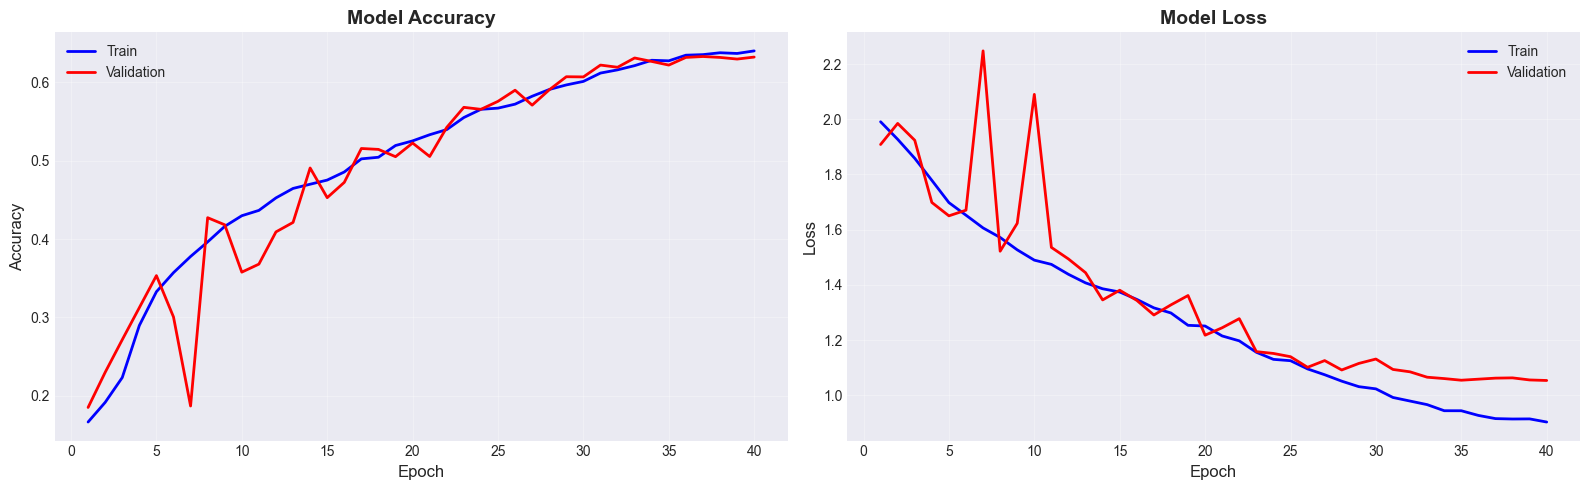

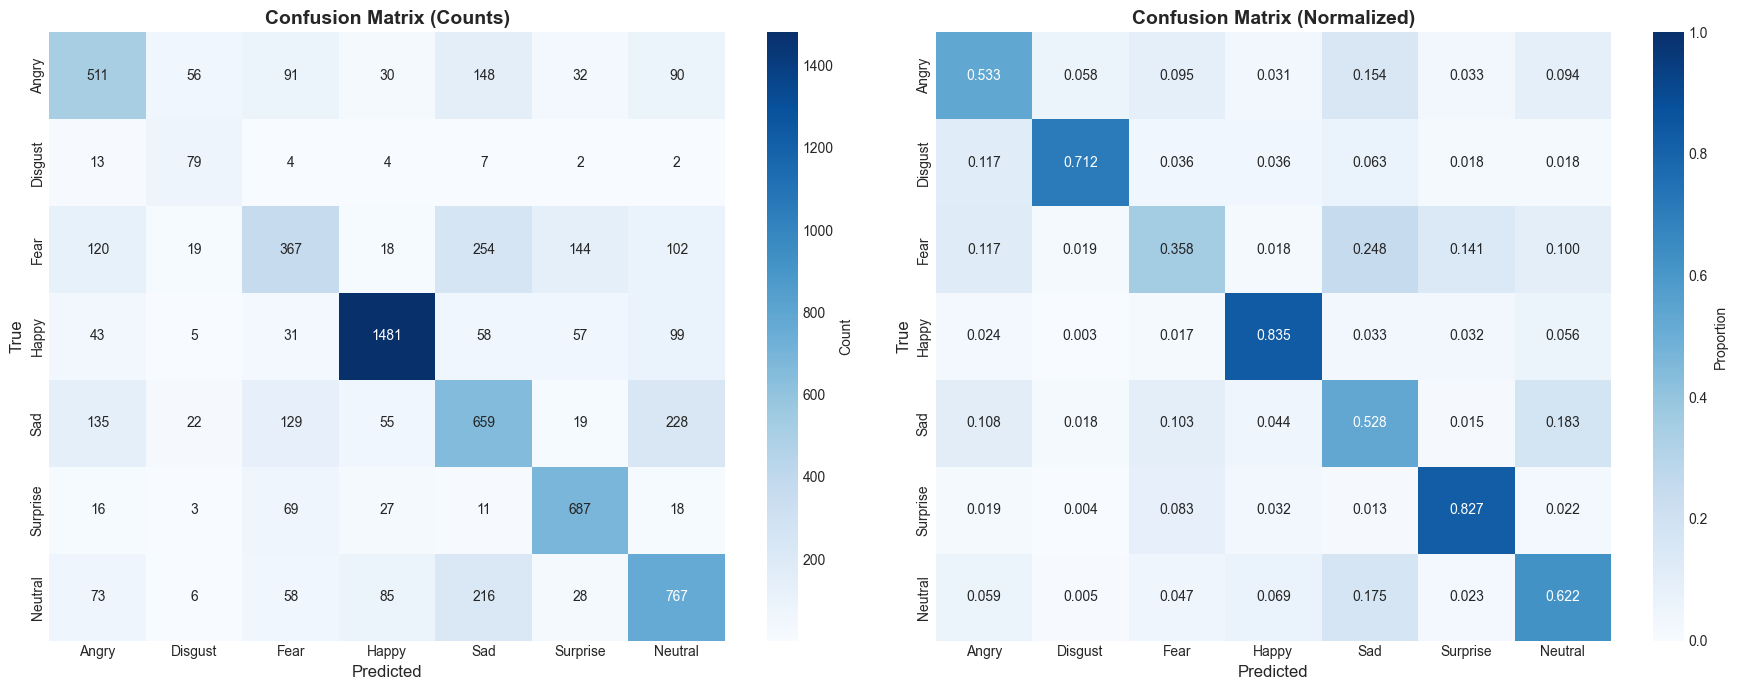


Saving final outputs...
💾 Final model saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\emotion_pytorch_final.pth
💾 History saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\training_history.csv
💾 Model info saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\model_info.json

🎉 ALL DONE!
Training time: 29.1 minutes (0.49 hours)
Best validation accuracy: 63.27%
Test accuracy: 63.40%
Models saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models
Results saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results

DETAILED ANALYSIS

Detailed Per-Class Metrics:
Emotion      Accuracy   Precision    Recall     F1-Score   Support   
-----------------------------------------------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image as PILImage

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# For live plotting in Jupyter
try:
    from IPython.display import clear_output
    JUPYTER_MODE = True
except:
    JUPYTER_MODE = False

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

# ============================================================================
# Configuration
# ============================================================================

PROCESSED_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\data\processed\emotions")
MODELS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 0.001
NUM_WORKERS = 0  # Set to 0 for Windows to avoid multiprocessing errors

print(f"\nConfiguration:")
print(f"  Device: {device}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")

# ============================================================================
# Load Data
# ============================================================================

print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

X_train = np.load(PROCESSED_DIR / 'X_train.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
X_val = np.load(PROCESSED_DIR / 'X_val.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy')
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

with open(PROCESSED_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

EMOTION_LABELS = metadata['class_labels']
class_weights_dict = metadata['class_weights']
NUM_CLASSES = len(EMOTION_LABELS)

print(f"\nLoaded:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"  Value range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"  Emotions: {EMOTION_LABELS}")
print(f"\n✅ Data already normalized [0,1]")

# ============================================================================
# PyTorch Dataset
# ============================================================================

class EmotionDataset(Dataset):
    """PyTorch dataset for emotion recognition."""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert to PIL Image for transforms
        image = (image * 255).astype(np.uint8)  # Scale to [0, 255]
        image = image.squeeze()  # Remove channel dim
        image = PILImage.fromarray(image, mode='L')  # L = grayscale

        if self.transform:
            image = self.transform(image)

        return image, label


# Training augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),  # Converts to [0, 1] and (C, H, W)
])

# Validation/test (no augmentation)
val_transform = transforms.Compose([
    transforms.ToTensor()
])

# Create datasets
train_dataset = EmotionDataset(X_train, y_train, transform=train_transform)
val_dataset = EmotionDataset(X_val, y_val, transform=val_transform)
test_dataset = EmotionDataset(X_test, y_test, transform=val_transform)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"\n✅ Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test data loading
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  Images: {sample_batch.shape}")
print(f"  Labels: {sample_labels.shape}")
print(f"  Image range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

# ============================================================================
# Model Definition
# ============================================================================

class ResidualBlock(nn.Module):
    """Residual block with skip connection."""

    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.skip(residual)
        out = self.relu(out)

        return out


class EmotionNet(nn.Module):
    """ResNet-style network for emotion recognition."""

    def __init__(self, num_classes=7):
        super(EmotionNet, self).__init__()

        # Initial conv
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Residual blocks
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        # Global pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.fc1 = nn.Linear(512, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(256, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial conv
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Residual blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Global pool
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # Classifier
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x


# Create model
model = EmotionNet(num_classes=NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*70}")
print(f"MODEL CREATED")
print(f"{'='*70}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")
print(f"{'='*70}")

# ============================================================================
# Training Setup
# ============================================================================

# Loss function with class weights
class_weights = torch.FloatTensor([class_weights_dict[i] for i in range(NUM_CLASSES)]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f"\n✅ Training setup complete:")
print(f"  Criterion: CrossEntropyLoss (weighted)")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, wd=1e-4)")
print(f"  Scheduler: CosineAnnealing")

# ============================================================================
# Training Functions
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Validate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def plot_training_progress(history, current_epoch):
    """Plot training progress in real-time."""
    if JUPYTER_MODE:
        clear_output(wait=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    epochs_range = range(1, len(history['train_acc']) + 1)

    # Accuracy plot
    axes[0].plot(epochs_range, history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[0].plot(epochs_range, history['val_acc'], 'r-o', label='Validation', linewidth=2, markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Loss plot
    axes[1].plot(epochs_range, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[1].plot(epochs_range, history['val_loss'], 'r-o', label='Validation', linewidth=2, markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Learning rate plot
    axes[2].plot(epochs_range, history['lr'], 'g-o', linewidth=2, markersize=4)
    axes[2].set_xlabel('Epoch', fontsize=11)
    axes[2].set_ylabel('Learning Rate', fontsize=11)
    axes[2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[2].grid(alpha=0.3)
    axes[2].set_yscale('log')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_progress_live.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print current status
    print(f"\n{'='*70}")
    print(f"Epoch {current_epoch}/{EPOCHS} Summary")
    print(f"{'='*70}")
    print(f"Train Acc: {history['train_acc'][-1]*100:.2f}% | Val Acc: {history['val_acc'][-1]*100:.2f}%")
    print(f"Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"Learning Rate: {history['lr'][-1]:.6f}")
    print(f"{'='*70}\n")


def print_training_summary(history, best_val_acc, training_time):
    """Print comprehensive training summary."""
    print(f"\n{'='*70}")
    print(f"📊 TRAINING SUMMARY")
    print(f"{'='*70}")

    print(f"\n⏱️  Duration:")
    print(f"   Total time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")
    print(f"   Epochs completed: {len(history['train_acc'])}")
    print(f"   Avg time/epoch: {training_time/len(history['train_acc']):.2f} min")

    print(f"\n📈 Performance:")
    print(f"   Best val accuracy: {best_val_acc*100:.2f}%")
    print(f"   Final val accuracy: {history['val_acc'][-1]*100:.2f}%")
    print(f"   Improvement: {(history['val_acc'][-1] - history['val_acc'][0])*100:.2f}%")

    print(f"\n📉 Loss:")
    print(f"   Initial train loss: {history['train_loss'][0]:.4f}")
    print(f"   Final train loss: {history['train_loss'][-1]:.4f}")
    print(f"   Final val loss: {history['val_loss'][-1]:.4f}")
    print(f"   Loss reduction: {(history['train_loss'][0] - history['train_loss'][-1]):.4f}")

    # Check for overfitting
    train_val_gap = history['train_acc'][-1] - history['val_acc'][-1]
    if train_val_gap > 0.1:
        print(f"\n⚠️  Warning: Possible overfitting detected!")
        print(f"   Train-Val accuracy gap: {train_val_gap*100:.2f}%")
    else:
        print(f"\n✅ Good generalization (Train-Val gap: {train_val_gap*100:.2f}%)")

    print(f"{'='*70}\n")

# ============================================================================
# Training Loop
# ============================================================================

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
patience = 10
patience_counter = 0

print(f"\n{'='*70}")
print(f"STARTING TRAINING")
print(f"{'='*70}")
print(f"Epochs: {EPOCHS}")
print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples: {len(val_dataset):,}")
print(f"Early stopping patience: {patience}")
print(f"{'='*70}\n")

start_time = datetime.now()

for epoch in range(EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*70}")

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Live visualization (every epoch)
    plot_training_progress(history, epoch + 1)

    # Save best model
    if val_acc > best_val_acc:
        improvement = val_acc - best_val_acc
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'history': history,
        }, MODELS_DIR / 'emotion_pytorch_best.pth')
        print(f"✅ NEW BEST MODEL! Val Acc: {val_acc*100:.2f}% (+{improvement*100:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️  No improvement. Patience: {patience_counter}/{patience}")

    # Early stopping
    if patience_counter >= patience:
        print(f"\n{'='*70}")
        print(f"🛑 EARLY STOPPING TRIGGERED")
        print(f"{'='*70}")
        print(f"No improvement for {patience} consecutive epochs")
        print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
        print(f"{'='*70}")
        break

    # Time estimation
    elapsed = (datetime.now() - start_time).total_seconds() / 60
    avg_time_per_epoch = elapsed / (epoch + 1)
    estimated_remaining = avg_time_per_epoch * (EPOCHS - epoch - 1)
    print(f"\n⏱️  Time elapsed: {elapsed:.1f}m | Estimated remaining: {estimated_remaining:.1f}m")

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print(f"\n{'='*70}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*70}")
print(f"Total time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")
print(f"Epochs trained: {len(history['train_acc'])}/{EPOCHS}")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Final validation accuracy: {history['val_acc'][-1]*100:.2f}%")
print(f"{'='*70}")

# Print training summary
print_training_summary(history, best_val_acc, training_time)

# ============================================================================
# Evaluation
# ============================================================================

print(f"\n{'='*70}")
print(f"EVALUATION")
print(f"{'='*70}")

# Load best model
checkpoint = torch.load(MODELS_DIR / 'emotion_pytorch_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Val accuracy: {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
print(f"\nEvaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*70}")
print(f"TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*70}")

# Get all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print(f"\n{classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, digits=4)}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(f"\nPer-Class Accuracy:")
for i, emotion in enumerate(EMOTION_LABELS):
    print(f"  {emotion.capitalize():12s}: {per_class_acc[i]:.4f} ({per_class_acc[i]*100:.2f}%)")

# ============================================================================
# Final Visualizations
# ============================================================================

print(f"\nGenerating final visualizations...")

# Training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs_range = range(1, len(history['train_acc']) + 1)

axes[0].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_acc'], 'r-', label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[e.capitalize() for e in EMOTION_LABELS],
            yticklabels=[e.capitalize() for e in EMOTION_LABELS],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[e.capitalize() for e in EMOTION_LABELS],
            yticklabels=[e.capitalize() for e in EMOTION_LABELS],
            ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# Save Model and Results
# ============================================================================

print(f"\nSaving final outputs...")

# Save final model
torch.save(model.state_dict(), MODELS_DIR / 'emotion_pytorch_final.pth')
print(f"💾 Final model saved: {MODELS_DIR / 'emotion_pytorch_final.pth'}")

# Save history
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)
print(f"💾 History saved: {RESULTS_DIR / 'training_history.csv'}")

# Save metadata
model_info = {
    'model_name': 'EmotionNet PyTorch',
    'architecture': 'ResNet-style CNN',
    'parameters': int(total_params),
    'num_classes': NUM_CLASSES,
    'emotion_labels': EMOTION_LABELS,
    'training': {
        'epochs_trained': len(history['train_acc']),
        'max_epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'training_time_minutes': float(training_time),
        'early_stopped': patience_counter >= patience,
    },
    'performance': {
        'best_val_acc': float(best_val_acc),
        'final_val_acc': float(history['val_acc'][-1]),
        'test_acc': float(test_acc),
        'test_loss': float(test_loss),
        'per_class_accuracy': {EMOTION_LABELS[i]: float(per_class_acc[i]) for i in range(NUM_CLASSES)}
    },
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'device': str(device)
}

with open(RESULTS_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"💾 Model info saved: {RESULTS_DIR / 'model_info.json'}")

print(f"\n{'='*70}")
print(f"🎉 ALL DONE!")
print(f"{'='*70}")
print(f"Training time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Models saved to: {MODELS_DIR}")
print(f"Results saved to: {RESULTS_DIR}")
print(f"{'='*70}")

# ============================================================================
# Additional Metrics and Analysis
# ============================================================================

print(f"\n{'='*70}")
print(f"DETAILED ANALYSIS")
print(f"{'='*70}")

# Calculate precision, recall, F1 for each class
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

print(f"\nDetailed Per-Class Metrics:")
print(f"{'Emotion':<12} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print(f"{'-'*70}")
for i, emotion in enumerate(EMOTION_LABELS):
    print(f"{emotion.capitalize():<12} {per_class_acc[i]:<10.4f} {precision[i]:<12.4f} "
          f"{recall[i]:<10.4f} {f1[i]:<10.4f} {support[i]:<10}")

# Overall metrics
print(f"\nOverall Metrics:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {precision.mean():.4f} (macro avg)")
print(f"  Recall:    {recall.mean():.4f} (macro avg)")
print(f"  F1-Score:  {f1.mean():.4f} (macro avg)")

# Identify best and worst performing classes
best_class_idx = per_class_acc.argmax()
worst_class_idx = per_class_acc.argmin()

print(f"\nBest performing class: {EMOTION_LABELS[best_class_idx].capitalize()} ({per_class_acc[best_class_idx]*100:.2f}%)")
print(f"Worst performing class: {EMOTION_LABELS[worst_class_idx].capitalize()} ({per_class_acc[worst_class_idx]*100:.2f}%)")

# Training stability
train_val_gap = [history['train_acc'][i] - history['val_acc'][i] for i in range(len(history['train_acc']))]
avg_gap = np.mean(train_val_gap)
final_gap = train_val_gap[-1]

print(f"\nTraining Stability:")
print(f"  Average train-val gap: {avg_gap*100:.2f}%")
print(f"  Final train-val gap: {final_gap*100:.2f}%")
if final_gap < 0.05:
    print(f"  ✅ Excellent generalization")
elif final_gap < 0.10:
    print(f"  ✅ Good generalization")
elif final_gap < 0.15:
    print(f"  ⚠️  Slight overfitting")
else:
    print(f"  ⚠️  Significant overfitting detected")

print(f"{'='*70}")

# ============================================================================
# Save Complete Training Log
# ============================================================================

# Create a comprehensive log file
log_file = RESULTS_DIR / 'training_log.txt'
with open(log_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("EMOTION DETECTION MODEL - TRAINING LOG\n")
    f.write("="*70 + "\n\n")

    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Device: {device}\n\n")

    f.write("CONFIGURATION\n")
    f.write("-"*70 + "\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Max Epochs: {EPOCHS}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Patience: {patience}\n\n")

    f.write("MODEL ARCHITECTURE\n")
    f.write("-"*70 + "\n")
    f.write(f"Total Parameters: {total_params:,}\n")
    f.write(f"Trainable Parameters: {trainable_params:,}\n\n")

    f.write("DATASET\n")
    f.write("-"*70 + "\n")
    f.write(f"Train Samples: {len(train_dataset):,}\n")
    f.write(f"Val Samples: {len(val_dataset):,}\n")
    f.write(f"Test Samples: {len(test_dataset):,}\n")
    f.write(f"Emotions: {', '.join(EMOTION_LABELS)}\n\n")

    f.write("TRAINING RESULTS\n")
    f.write("-"*70 + "\n")
    f.write(f"Epochs Trained: {len(history['train_acc'])}\n")
    f.write(f"Training Time: {training_time:.1f} minutes ({training_time/60:.2f} hours)\n")
    f.write(f"Early Stopped: {'Yes' if patience_counter >= patience else 'No'}\n")
    f.write(f"Best Val Accuracy: {best_val_acc*100:.2f}%\n")
    f.write(f"Final Val Accuracy: {history['val_acc'][-1]*100:.2f}%\n\n")

    f.write("TEST RESULTS\n")
    f.write("-"*70 + "\n")
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\n")
    f.write(f"Test Loss: {test_loss:.4f}\n\n")

    f.write("PER-CLASS PERFORMANCE\n")
    f.write("-"*70 + "\n")
    f.write(f"{'Emotion':<12} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} {'F1-Score':<10}\n")
    f.write("-"*70 + "\n")
    for i, emotion in enumerate(EMOTION_LABELS):
        f.write(f"{emotion.capitalize():<12} {per_class_acc[i]:<10.4f} {precision[i]:<12.4f} "
                f"{recall[i]:<10.4f} {f1[i]:<10.4f}\n")

    f.write("\n" + "="*70 + "\n")

print(f"\n💾 Training log saved: {log_file}")

print(f"\n{'='*70}")
print(f"📁 OUTPUT FILES")
print(f"{'='*70}")
print(f"Models:")
print(f"  ✓ {MODELS_DIR / 'emotion_pytorch_best.pth'}")
print(f"  ✓ {MODELS_DIR / 'emotion_pytorch_final.pth'}")
print(f"\nResults:")
print(f"  ✓ {RESULTS_DIR / 'training_history.csv'}")
print(f"  ✓ {RESULTS_DIR / 'training_history.png'}")
print(f"  ✓ {RESULTS_DIR / 'confusion_matrix.png'}")
print(f"  ✓ {RESULTS_DIR / 'training_progress_live.png'}")
print(f"  ✓ {RESULTS_DIR / 'model_info.json'}")
print(f"  ✓ {RESULTS_DIR / 'training_log.txt'}")
print(f"{'='*70}")

print(f"\n✨ Training complete! Model ready for deployment.")
print(f"💡 To use the model, load: {MODELS_DIR / 'emotion_pytorch_best.pth'}")

Device: cuda

Loading data...
Train: (24402, 48, 48, 1), Val: (4307, 48, 48, 1), Test: (7178, 48, 48, 1)

Training 5 models for ensemble

Training Model 0
Epoch 1/40 - Train Acc: 16.08% - Val Acc: 16.67%
Epoch 2/40 - Train Acc: 16.47% - Val Acc: 15.58%
Epoch 3/40 - Train Acc: 17.71% - Val Acc: 19.13%
Epoch 4/40 - Train Acc: 21.10% - Val Acc: 27.86%
Epoch 5/40 - Train Acc: 26.09% - Val Acc: 24.68%
Epoch 6/40 - Train Acc: 30.58% - Val Acc: 31.72%
Epoch 7/40 - Train Acc: 36.35% - Val Acc: 39.75%
Epoch 8/40 - Train Acc: 39.43% - Val Acc: 34.11%
Epoch 9/40 - Train Acc: 41.34% - Val Acc: 34.32%
Epoch 10/40 - Train Acc: 42.75% - Val Acc: 39.08%
Epoch 11/40 - Train Acc: 43.97% - Val Acc: 38.08%
Epoch 12/40 - Train Acc: 45.27% - Val Acc: 43.28%
Epoch 13/40 - Train Acc: 46.63% - Val Acc: 45.23%
Epoch 14/40 - Train Acc: 47.46% - Val Acc: 49.78%
Epoch 15/40 - Train Acc: 48.31% - Val Acc: 46.85%
Epoch 16/40 - Train Acc: 49.01% - Val Acc: 51.01%
Epoch 17/40 - Train Acc: 50.44% - Val Acc: 48.97%
Epoc

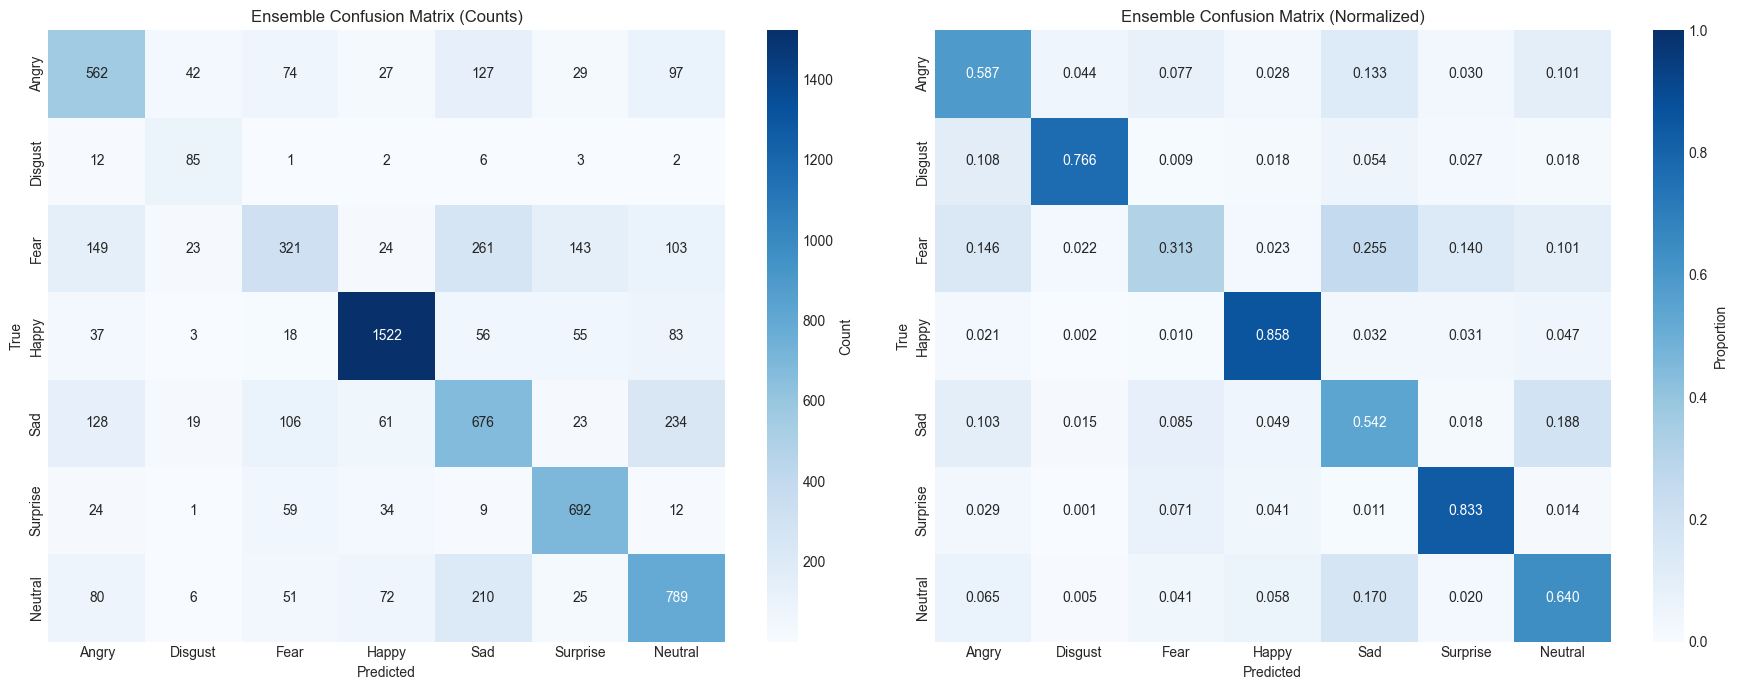

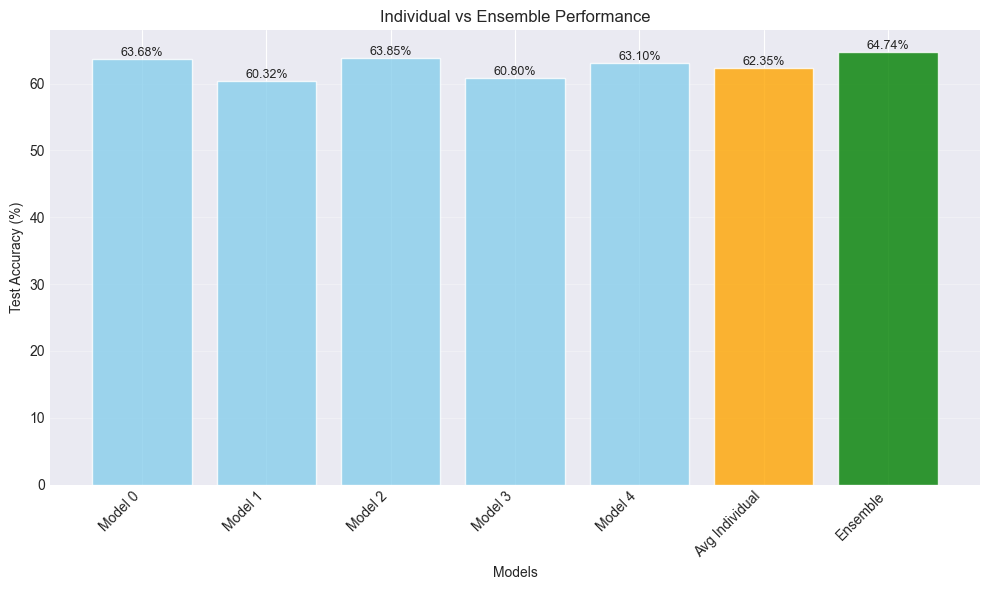


Results saved to C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\ensemble
Models saved to C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\ensemble

Final Ensemble Accuracy: 64.74%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime
from tqdm import tqdm
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image as PILImage

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = (image * 255).astype(np.uint8)
        image = image.squeeze()
        image = PILImage.fromarray(image, mode='L')
        if self.transform:
            image = self.transform(image)
        return image, label


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.skip(residual)
        out = self.relu(out)
        return out


class EmotionNet(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.bn_fc2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds)
    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    return all_preds, all_probs, all_labels


def train_single_model(model_id, train_loader, val_loader, device, class_weights,
                       num_classes, models_dir, epochs=40, lr=0.001, patience=10):
    print(f"\n{'='*70}")
    print(f"Training Model {model_id}")
    print(f"{'='*70}")

    seed = 42 + model_id * 100
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    model = EmotionNet(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_acc = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc*100:.2f}% - Val Acc: {val_acc*100:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'seed': seed
            }, models_dir / f'ensemble_model_{model_id}.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    checkpoint = torch.load(models_dir / f'ensemble_model_{model_id}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    return model, best_val_acc, history


def ensemble_predict(models, loader, device, method='average'):
    all_probs_list = []
    labels = None

    for model in models:
        model.eval()
        probs_batch = []
        labels_batch = []
        with torch.no_grad():
            for images, batch_labels in loader:
                images = images.to(device)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                probs_batch.append(probs.cpu().numpy())
                labels_batch.extend(batch_labels.numpy())
        all_probs_list.append(np.vstack(probs_batch))
        if labels is None:
            labels = np.array(labels_batch)

    if method == 'average':
        ensemble_probs = np.mean(all_probs_list, axis=0)
    elif method == 'voting':
        predictions = [np.argmax(probs, axis=1) for probs in all_probs_list]
        predictions = np.array(predictions)
        ensemble_preds = []
        for i in range(predictions.shape[1]):
            votes = np.bincount(predictions[:, i])
            ensemble_preds.append(np.argmax(votes))
        return np.array(ensemble_preds), labels

    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    return ensemble_preds, labels


def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    PROCESSED_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\data\processed\emotions")
    MODELS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\ensemble")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\ensemble")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    BATCH_SIZE = 64
    EPOCHS = 40
    LEARNING_RATE = 0.001
    NUM_WORKERS = 0
    NUM_MODELS = 5

    print("\nLoading data...")
    X_train = np.load(PROCESSED_DIR / 'X_train.npy')
    y_train = np.load(PROCESSED_DIR / 'y_train.npy')
    X_val = np.load(PROCESSED_DIR / 'X_val.npy')
    y_val = np.load(PROCESSED_DIR / 'y_val.npy')
    X_test = np.load(PROCESSED_DIR / 'X_test.npy')
    y_test = np.load(PROCESSED_DIR / 'y_test.npy')

    with open(PROCESSED_DIR / 'metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)

    EMOTION_LABELS = metadata['class_labels']
    class_weights_dict = metadata['class_weights']
    NUM_CLASSES = len(EMOTION_LABELS)

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ])

    val_transform = transforms.Compose([transforms.ToTensor()])

    train_dataset = EmotionDataset(X_train, y_train, transform=train_transform)
    val_dataset = EmotionDataset(X_val, y_val, transform=val_transform)
    test_dataset = EmotionDataset(X_test, y_test, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    class_weights = torch.FloatTensor([class_weights_dict[i] for i in range(NUM_CLASSES)]).to(device)

    print(f"\n{'='*70}")
    print(f"Training {NUM_MODELS} models for ensemble")
    print(f"{'='*70}")

    models = []
    val_accuracies = []
    histories = []

    for i in range(NUM_MODELS):
        model, best_val_acc, history = train_single_model(
            model_id=i,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            class_weights=class_weights,
            num_classes=NUM_CLASSES,
            models_dir=MODELS_DIR,
            epochs=EPOCHS,
            lr=LEARNING_RATE,
            patience=10
        )
        models.append(model)
        val_accuracies.append(best_val_acc)
        histories.append(history)
        print(f"Model {i} - Best Val Acc: {best_val_acc*100:.2f}%")

    print(f"\n{'='*70}")
    print("Individual Model Performance")
    print(f"{'='*70}")
    for i, acc in enumerate(val_accuracies):
        print(f"Model {i}: {acc*100:.2f}%")
    print(f"Average: {np.mean(val_accuracies)*100:.2f}%")
    print(f"Std Dev: {np.std(val_accuracies)*100:.2f}%")

    print(f"\n{'='*70}")
    print("Testing Ensemble Methods")
    print(f"{'='*70}")

    print("\nMethod 1: Probability Averaging")
    ensemble_preds_avg, test_labels = ensemble_predict(models, test_loader, device, method='average')
    acc_avg = accuracy_score(test_labels, ensemble_preds_avg)
    print(f"Test Accuracy (Averaging): {acc_avg*100:.2f}%")

    print("\nMethod 2: Majority Voting")
    ensemble_preds_vote, _ = ensemble_predict(models, test_loader, device, method='voting')
    acc_vote = accuracy_score(test_labels, ensemble_preds_vote)
    print(f"Test Accuracy (Voting): {acc_vote*100:.2f}%")

    best_method = 'average' if acc_avg > acc_vote else 'voting'
    best_preds = ensemble_preds_avg if acc_avg > acc_vote else ensemble_preds_vote
    best_acc = max(acc_avg, acc_vote)

    print(f"\nBest ensemble method: {best_method.upper()}")
    print(f"Best ensemble accuracy: {best_acc*100:.2f}%")

    print("\nIndividual model accuracies on test set:")
    individual_accs = []
    for i, model in enumerate(models):
        preds, _, _ = get_predictions(model, test_loader, device)
        acc = accuracy_score(test_labels, preds)
        individual_accs.append(acc)
        print(f"Model {i}: {acc*100:.2f}%")

    print(f"\nImprovement over best individual model: +{(best_acc - max(individual_accs))*100:.2f}%")
    print(f"Improvement over average individual model: +{(best_acc - np.mean(individual_accs))*100:.2f}%")

    print(f"\n{'='*70}")
    print("Detailed Classification Report (Best Ensemble)")
    print(f"{'='*70}")
    print(classification_report(test_labels, best_preds, target_names=EMOTION_LABELS, digits=4))

    cm = confusion_matrix(test_labels, best_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    print("\nPer-Class Accuracy:")
    for i, emotion in enumerate(EMOTION_LABELS):
        print(f"  {emotion.capitalize():12s}: {per_class_acc[i]:.4f} ({per_class_acc[i]*100:.2f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[e.capitalize() for e in EMOTION_LABELS],
                yticklabels=[e.capitalize() for e in EMOTION_LABELS],
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Ensemble Confusion Matrix (Counts)')

    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=[e.capitalize() for e in EMOTION_LABELS],
                yticklabels=[e.capitalize() for e in EMOTION_LABELS],
                ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Ensemble Confusion Matrix (Normalized)')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'ensemble_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    x_pos = np.arange(len(models) + 2)
    accuracies_plot = individual_accs + [np.mean(individual_accs), best_acc]
    labels_plot = [f'Model {i}' for i in range(len(models))] + ['Avg Individual', 'Ensemble']
    colors = ['skyblue'] * len(models) + ['orange', 'green']

    bars = ax.bar(x_pos, [a*100 for a in accuracies_plot], color=colors, alpha=0.8)
    ax.set_xlabel('Models')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Individual vs Ensemble Performance')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_plot, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    for i, (bar, acc) in enumerate(zip(bars, accuracies_plot)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'ensemble_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    results = {
        'num_models': NUM_MODELS,
        'individual_accuracies': [float(acc) for acc in individual_accs],
        'val_accuracies': [float(acc) for acc in val_accuracies],
        'ensemble_method': best_method,
        'ensemble_accuracy': float(best_acc),
        'averaging_accuracy': float(acc_avg),
        'voting_accuracy': float(acc_vote),
        'improvement_over_best': float(best_acc - max(individual_accs)),
        'improvement_over_avg': float(best_acc - np.mean(individual_accs)),
        'per_class_accuracy': {EMOTION_LABELS[i]: float(per_class_acc[i]) for i in range(NUM_CLASSES)},
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    with open(RESULTS_DIR / 'ensemble_results.json', 'w') as f:
        json.dump(results, f, indent=4)

    print(f"\nResults saved to {RESULTS_DIR}")
    print(f"Models saved to {MODELS_DIR}")
    print(f"\nFinal Ensemble Accuracy: {best_acc*100:.2f}%")


if __name__ == '__main__':
    main()